# EV-FLOW Planner Study — data, cleaning, and modelling groundwork

**Purpose.** Working study for Epics 4 and 5 (Strategic SPKLU Placement Optimization and the
site feasibility dashboard). This notebook answers three questions honestly:

1. **What data do we already hold**, and what state is it in?
2. **What does our production cleaning pipeline actually do** — run here end-to-end on the raw
   files, reproducing the deployed numbers exactly?
3. **What does the reference methodology give us** ([akansh12/data-science-Optimal-EV-station-placement](https://github.com/akansh12/data-science-Optimal-EV-station-placement)),
   what transfers to Jabodetabek, and what must be different?

**Provenance rules used throughout:** every figure states where its data came from; simulated or
proxy data is labelled as such; nothing is trained on features that leak the label.

*EV-FLOW · iteration 3 groundwork · runs offline, no database required.*

## 1 · Setup

Only the scientific stack that is already installed is used (`pandas`, `numpy`, `matplotlib`,
`scikit-learn`, `scipy`, `pyarrow`). Deliberately **no** `geopandas`/`fiona`/`pyproj`: the grid
GeoPackage ships centroid columns and is read with plain `sqlite3`, and WGS84→UTM 48S is a
20-line Snyder transform validated against a known landmark below.

In [1]:
from pathlib import Path
import json, math, sqlite3, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
plt.rcParams['figure.dpi'] = 110

STUDY_DIR   = Path.cwd()
REPO_ROOT   = STUDY_DIR.parent                      # evflow-fullstack/
BACKEND     = REPO_ROOT / 'backend-ev-flow'
RAW         = BACKEND / 'data' / 'raw'
PROCESSED   = BACKEND / 'data' / 'processed'
REFERENCE   = Path('/Users/mvvkur/Documents/iterasi3-evflow/data-science-Optimal-EV-station-placement')
OUT         = STUDY_DIR / 'output'
OUT.mkdir(exist_ok=True)

sys.path.insert(0, str(BACKEND))                    # import the real production modules

for p in [RAW, PROCESSED, REFERENCE]:
    print(('OK  ' if p.exists() else 'MISSING  ') + str(p))

OK  /Users/mvvkur/Documents/backend-ev-flow/evflow-fullstack/backend-ev-flow/data/raw
OK  /Users/mvvkur/Documents/backend-ev-flow/evflow-fullstack/backend-ev-flow/data/processed
OK  /Users/mvvkur/Documents/iterasi3-evflow/data-science-Optimal-EV-station-placement


### 1.1 Coordinate systems

Two live in this study, and mixing them silently is the classic siting bug:

| CRS | Used by | Units |
|---|---|---|
| **EPSG:4326** (WGS84 lat/lon) | our database (`stations.geom`), all raw feeds | degrees |
| **EPSG:32748** (UTM zone 48S) | the team's 500 m grid, all area/distance maths | metres |

The forward transform below is Snyder's Transverse Mercator series (sub-metre accuracy at this
extent). Validation: Monas must land at ≈ E 702.2 km, N 9317.1 km.

In [2]:
def wgs84_to_utm48s(lat, lon):
    """WGS84 -> EPSG:32748 (UTM 48S). Snyder series, sub-metre at Jabodetabek extent."""
    a, f, k0 = 6378137.0, 1 / 298.257223563, 0.9996
    lon0 = math.radians(105.0)                       # zone 48 central meridian
    e2 = f * (2 - f); ep2 = e2 / (1 - e2)
    la, lo = math.radians(lat), math.radians(lon)
    N = a / math.sqrt(1 - e2 * math.sin(la) ** 2)
    T = math.tan(la) ** 2
    Cc = ep2 * math.cos(la) ** 2
    A = (lo - lon0) * math.cos(la)
    M = a * ((1 - e2/4 - 3*e2**2/64 - 5*e2**3/256) * la
             - (3*e2/8 + 3*e2**2/32 + 45*e2**3/1024) * math.sin(2*la)
             + (15*e2**2/256 + 45*e2**3/1024) * math.sin(4*la)
             - (35*e2**3/3072) * math.sin(6*la))
    x = k0*N*(A + (1-T+Cc)*A**3/6 + (5-18*T+T**2+72*Cc-58*ep2)*A**5/120) + 500_000
    y = k0*(M + N*math.tan(la)*(A**2/2 + (5-T+9*Cc+4*Cc**2)*A**4/24
            + (61-58*T+T**2+600*Cc-330*ep2)*A**6/720)) + 10_000_000
    return x, y

mx, my = wgs84_to_utm48s(-6.1754, 106.8272)          # Monas
print(f'Monas -> E {mx:,.0f}  N {my:,.0f}')
assert abs(mx - 702_183) < 50 and abs(my - 9_317_059) < 50, 'UTM transform drifted'

Monas -> E 702,183  N 9,317,059


## 2 · Data inventory — what we hold

### 2.1 Raw station feeds

Three snapshots, exactly the files the production ingest (`scripts/ingest_raw.py`) loads into the
`raw_station_records` staging table.

In [3]:
pln = json.load(open(RAW / '_petaspklu_all.json'))
ocm = json.load(open(RAW / 'ocm_jakarta.json'))
osm = json.load(open(RAW / 'osm_charging_jakarta.json'))['elements']

inventory = pd.DataFrame([
    ['PLN SPKLU',       'pln_spklu',        len(pln), 'official operator registry (all Indonesia)'],
    ['Open Charge Map', 'open_charge_map',  len(ocm), 'community DB, CC BY 4.0, Jakarta pull'],
    ['OpenStreetMap',   'osm',              len(osm), 'Overpass amenity=charging_station, Jakarta'],
], columns=['feed', 'source id', 'records', 'notes'])
inventory

,feed,source id,records,notes
0,PLN SPKLU,pln_spklu,3029,official operator registry (all Indonesia)
1,Open Charge Map,open_charge_map,527,"community DB, CC BY 4.0, Jakarta pull"
2,OpenStreetMap,osm,13,"Overpass amenity=charging_station, Jakarta"


In [4]:
# one record from each feed, trimmed to its identifying fields
print('PLN  :', {k: pln[0][k] for k in ['id','nama_lokasi','provinsi','latitude','longitude','total_konektor']})
print('OCM  :', {'ID': ocm[0]['ID'], 'Title': ocm[0]['AddressInfo']['Title'],
                 'NumberOfPoints': ocm[0].get('NumberOfPoints')})
print('OSM  :', {'id': osm[0]['id'], 'tags': {k: v for k, v in list(osm[0].get('tags', {}).items())[:4]}})

PLN  : {'id': 1, 'nama_lokasi': 'SPKLU PLN UID JAKARTA RAYA', 'provinsi': 'DKI Jakarta ', 'latitude': '-6.1803900', 'longitude': '106.8331910', 'total_konektor': 0}
OCM  : {'ID': 479002, 'Title': 'PLN ULP Babelan', 'NumberOfPoints': 1}
OSM  : {'id': 6222913188, 'tags': {'amenity': 'charging_station', 'operator': 'BPPT'}}


### 2.2 Everything else on disk

| Asset | Where | Size / shape | State |
|---|---|---|---|
| EV catalogue (Indonesia) | `data/raw/indonesia_ev_specs_pricing_2026.csv` | 60 models | serves the app's vehicle profiles |
| EV catalogue (global) | `ev_dataset.zip → electric_vehicles_spec_2025.csv` | 478 models | merged into `ev_models` (535 after union) |
| Early unified parquet | `data/processed/stations_unified.parquet` | 1,682 × 7 | **superseded** — pre-dates the current dedup; kept as history |
| Reference dataset | reference repo `data/processed/all_city_data_with_pop.csv` | 10,824 cells × 25 | 6 German cities, the model's training data |
| **Team's 500 m grid (current)** | `ev-planner-study/grid_jabodetabek_500m.gpkg` | 28,176 cells | EPSG:32748, `kota` label + boundary `overlap_frac` per cell |
| ADM2 boundaries | `ev-planner-study/jabodetabek_adm2.gpkg` | **14** units | geoBoundaries gbOpen (CC BY 3.0 IGO) — incl. Kepulauan Seribu as its own unit |
| Acquisition pipeline | `ev-planner-study/spklu_bootstrap.py` | 6 subcommands | grid · substations (BIG) · Zenodo labels · OCM · population (WorldPop) · POI (PBF), licences recorded in the docstring |
| Earlier grid iteration | reference repo `data/processed/jabodetabek_grid.gpkg` | 27,941 cells | labelled from OSM alone → **19** positive cells; superseded by the grid above |

### 2.3 What we do **not** hold yet

Nothing below exists anywhere in the repo or database (verified by full-repo audit):
**population** (GHS-POP / BPS), **POI counts**, **land-use shares**, **zoning**, **substation
capacity (MVA)**, **commuter flows**, and — most importantly — **any utilisation label** for a
supervised target. The extraction plan (`jabodetabek_data_extraction` diagram) maps each to a
source; Zenodo 16946731 (137 Greater Jakarta sites with utilisation labels) is the only real
target-variable candidate.

## 3 · Cleaning — the production pipeline, run here

This is **not a re-implementation**. The cells below import the deployed modules
(`api/sources.py`, `api/dedup.py`, `api/services/service_area.py`) and run them on the raw files.
The only substitution is the staging seam `sources._staged`, which normally reads the
`raw_station_records` table — here it reads the same three files that table is loaded from.

Pipeline: **normalise** (field mapping, connector derivation, drop null coords) →
**de-duplicate** across sources (75 m greedy merge, PLN > OCM > OSM priority) →
**service-area filter** (the Jabodetabek box the app itself enforces).

In [5]:
import api.sources as sources
from api.dedup import cluster_stations
from api.services import service_area

_files = {
    sources.PLN_SOURCE: lambda: pln,
    sources.OCM_SOURCE: lambda: ocm,
    sources.OSM_SOURCE: lambda: osm,
}
sources._staged = lambda src: _files[src]()          # the single DB seam

normalized = sources.normalized_rows()
merged     = cluster_stations(normalized)

W, S, E, N = service_area.station_area_bounds()      # the box the app enforces
jabodetabek = [r for r in merged if S <= r['latitude'] <= N and W <= r['longitude'] <= E]

print(f'raw records          : {len(pln) + len(ocm) + len(osm):>5}')
print(f'normalized           : {len(normalized):>5}   (null-coordinate rows dropped)')
print(f'after 75 m dedup     : {len(merged):>5}   (cross-source duplicates merged)')
print(f'inside Jabodetabek   : {len(jabodetabek):>5}   box (W,S,E,N) = {(W, S, E, N)}')

assert len(merged) == 2931, 'dedup no longer reproduces the deployed station count'
assert len(jabodetabek) == 1236, 'service-area filter no longer reproduces the deployed count'

raw records          :  3569
normalized           :  3569   (null-coordinate rows dropped)
after 75 m dedup     :  2931   (cross-source duplicates merged)
inside Jabodetabek   :  1236   box (W,S,E,N) = (106.25, -6.95, 107.25, -5.85)


Those two asserts pin this notebook to production reality: **2,931** stations nationally and
**1,236** in Jabodetabek are the exact counts the deployed API serves.

### 3.1 What the merge did

Each merged station keeps the provenance of every feed that contributed to it (`sources` list).

In [6]:
src_mix = pd.Series(
    [' + '.join(sorted(r['sources'])) if isinstance(r.get('sources'), (list, tuple))
     else r.get('source', '?') for r in merged]
).value_counts()
src_mix.to_frame('stations')

,stations
pln_spklu,2413
open_charge_map + pln_spklu,355
open_charge_map,150
open_charge_map + osm + pln_spklu,7
osm,6


In [7]:
jab = pd.DataFrame(jabodetabek)
jab['connector_count'] = jab['connectors'].apply(
    lambda cs: sum(c.get('count') or 1 for c in cs) if isinstance(cs, list) else 1)
print(f"Jabodetabek: {len(jab)} stations, {int(jab['connector_count'].sum())} connectors")
jab[['id','name','city','power_kw','speed_tier','connector_count']].head(6)

Jabodetabek: 1236 stations, 3434 connectors


,id,name,city,power_kw,speed_tier,connector_count
0,pln_spklu-1,SPKLU PLN UID JAKARTA RAYA,Kota ADM Jakarta Pusat,200.0,ultra_fast,17
1,pln_spklu-100,SPKLU Brilian 1,Kota ADM Jakarta Pusat,25.0,medium,3
2,pln_spklu-1015,SPKLU Apartemen Permata Eksekutif,Kota ADM Jakarta Barat,22.0,medium,2
3,pln_spklu-1016,SPKLU Louie Café,Kota ADM Jakarta Selatan,120.0,fast,7
4,pln_spklu-1017,SPKLU Apartement Kebagusan,Kota ADM Jakarta Selatan,22.0,medium,2
5,pln_spklu-102,SPKLU SUMMIT MAS,Kota ADM Jakarta Selatan,50.0,medium,5


### 3.2 Why cleaning is not optional here — the label dirt exhibit

`province` / `city` are free text from three differently-conventioned feeds. The same
administrative areas arrive under multiple spellings — including a typo that reached production
(`DKI Jakarya`). This is the concrete argument for joining labels **spatially** (HDX COD-AB
boundary polygons) instead of trusting source strings.

In [8]:
prov = pd.Series([r.get('province') for r in merged if r.get('province')])
jakarta_variants = sorted(v for v in prov.unique() if 'jak' in v.lower())
print('Jakarta arrives as :', jakarta_variants)
prov.value_counts().head(8).to_frame('stations')

Jakarta arrives as : ['DKI Jakarta', 'DKI Jakarta ', 'DKI Jakarya', 'Jakarta']


,stations
DKI Jakarta,696
Jawa Barat,522
Banten,280
Jawa Timur,230
Jawa Tengah,206
Bali,110
Sumatera Utara,99
Sumatera Barat,75


## 4 · EDA — the footprint we bring to siting

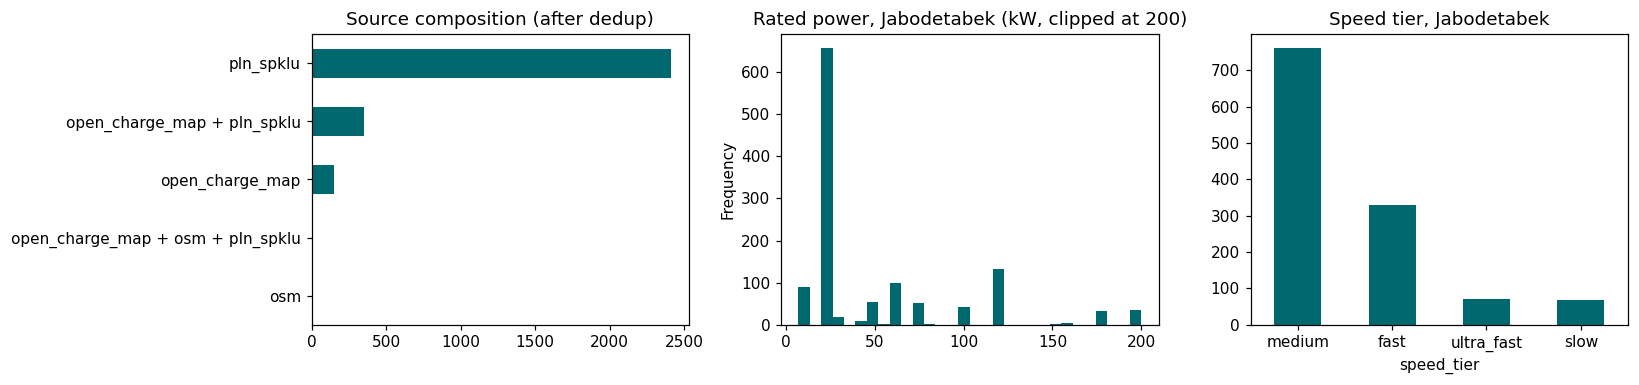

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

src_mix.plot.barh(ax=axes[0], color='#00696F')
axes[0].set_title('Source composition (after dedup)'); axes[0].invert_yaxis()

jab['power_kw'].dropna().clip(upper=200).plot.hist(bins=30, ax=axes[1], color='#00696F')
axes[1].set_title('Rated power, Jabodetabek (kW, clipped at 200)')

jab['speed_tier'].value_counts().plot.bar(ax=axes[2], color='#00696F')
axes[2].set_title('Speed tier, Jabodetabek'); axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout(); plt.show()

## 5 · The 500 m grid — the team's current cut, re-labelled with our footprint

The team's grid lives in this directory: **28,176 cells** at 500 m over the **14** ADM2 boundary
polygons (EPSG:32748), each carrying its `kota` and the fraction of the cell inside the boundary
(`overlap_frac`). An earlier iteration (27,941 cells, in the reference repo) was labelled from
the OSM feed alone and managed **19 positive cells** — our merged footprint is about to change
that by a factor of ~46.

A `.gpkg` *is* SQLite, and this one ships ready-made centroid columns, so plain `sqlite3` reads
it — no geospatial stack required.

In [10]:
GPKG = STUDY_DIR / 'grid_jabodetabek_500m.gpkg'

con = sqlite3.connect(GPKG)
cells = pd.read_sql_query(
    'SELECT cell_id, kota, overlap_frac, centroid_x AS cx, centroid_y AS cy, lon, lat FROM grid', con)
con.close()

# the superseded OSM-only label, for the before/after comparison
con = sqlite3.connect(REFERENCE / 'data' / 'processed' / 'jabodetabek_grid.gpkg')
osm_only_positive = con.execute(
    'SELECT count(*) FROM jabodetabek_grid WHERE has_station = 1').fetchone()[0]
con.close()

x0, y0 = cells.cx.min(), cells.cy.min()
cells['ix'] = ((cells.cx - x0) / 500).round().astype(int)
cells['iy'] = ((cells.cy - y0) / 500).round().astype(int)

print(f'cells: {len(cells):,} across {cells.kota.nunique()} kota/kabupaten'
      f'   | earlier OSM-only label: {osm_only_positive} positive cells')
assert len(cells) == 28176 and cells.kota.nunique() == 14
cells.groupby('kota').size().sort_values(ascending=False).to_frame('cells')

cells: 28,176 across 14 kota/kabupaten   | earlier OSM-only label: 19 positive cells


,cells
kota,
Bogor,12212
Bekasi,5300
Tangerang,4256
Kota Bekasi,862
Kota Depok,789
Kota Jakarta Timur,733
Kota Tangerang,725
Kota Tangerang Selatan,657
Kota Jakarta Utara,616


### 5.1 Phase-0 features from data we already hold

Stations are projected into the grid's CRS and binned by cell (the grid is regular, so binning is
exact). Per cell: **station count**, **connector capacity**, **distance to nearest station** and
**stations within 2 km** (both from a KD-tree in metres).

In [11]:
from scipy.spatial import cKDTree

st = jab.copy()
st[['ux', 'uy']] = [wgs84_to_utm48s(la, lo) for la, lo in zip(st.latitude, st.longitude)]

cell_index = {(i, j): cid for i, j, cid in zip(cells.ix, cells.iy, cells.cell_id)}
# x0/y0 are cell CENTROIDS, so cell edges sit at x0-250 + k*500
st['ix'] = ((st.ux - (x0 - 250)) // 500).astype(int)
st['iy'] = ((st.uy - (y0 - 250)) // 500).astype(int)
st['cell_id'] = [cell_index.get(k) for k in zip(st.ix, st.iy)]

in_grid = st.dropna(subset=['cell_id']).copy()
print(f'stations inside grid coverage : {len(in_grid)} of {len(st)} '
      f'({len(st) - len(in_grid)} fall in the box but outside the ADM2 mask — bay, fringes)')

per_cell = in_grid.groupby('cell_id').agg(
    station_count=('id', 'size'), connector_count=('connector_count', 'sum'))
cells = cells.merge(per_cell, on='cell_id', how='left')
cells[['station_count', 'connector_count']] = cells[['station_count', 'connector_count']].fillna(0).astype(int)

tree = cKDTree(in_grid[['ux', 'uy']].values)
cells['nearest_station_m'] = tree.query(cells[['cx', 'cy']].values)[0].round(0)
cells['stations_2km'] = tree.query_ball_point(cells[['cx', 'cy']].values, r=2000, return_length=True)

cells['has_station'] = cells.station_count > 0
print(f"cells with a station : {int(cells.has_station.sum())}  (OSM-only label had {osm_only_positive})")
assert cells.station_count.sum() == len(in_grid), 'binning lost or double-counted stations'

per_kota = cells.groupby('kota').agg(cells=('cell_id','size'),
                                     stations=('station_count','sum'),
                                     connectors=('connector_count','sum'))
per_kota['stations_per_100_cells'] = (100*per_kota.stations/per_kota.cells).round(1)
per_kota.sort_values('stations', ascending=False)

stations inside grid coverage : 1196 of 1236 (40 fall in the box but outside the ADM2 mask — bay, fringes)
cells with a station : 889  (OSM-only label had 19)


,cells,stations,connectors,stations_per_100_cells
kota,,,,
Kota Jakarta Selatan,583,261,823,44.8
Kota Jakarta Pusat,191,132,358,69.1
Kota Jakarta Timur,733,128,376,17.5
Kota Jakarta Barat,502,109,272,21.7
Kota Jakarta Utara,616,102,314,16.6
Tangerang,4256,92,278,2.2
Kota Tangerang Selatan,657,74,189,11.3
Kota Tangerang,725,66,174,9.1
Bogor,12212,64,128,0.5


**The label story in one line:** re-labelling the identical grid with our merged footprint
takes the positive class from 19 cells (0.07%) to ~880 (≈3.2%) — from untrainable to workable.
This, not any algorithm, is the project's data advantage.

## 6 · Gap analysis — first automated pinpoints (Epic 4 preview)

With only phase-0 features, a **coverage gap** is purely geometric: cells far from every existing
station. The score below is therefore honest about what it is — a *coverage* surface, not a
*demand* surface. Population, POI and land-use (phases 1–2) are what turn it into demand.

Method: score every cell by distance-to-nearest-station (capped at 10 km), keep the top decile,
and let `KMeans` (weighted by score) place **15 candidate pinpoints** — the same "automated
mathematical coordinates" shape Epic 4 asks for.

In [12]:
from sklearn.cluster import KMeans

cells['gap_score'] = (cells.nearest_station_m.clip(upper=10_000) / 10_000).round(4)

# Kepulauan Seribu is excluded from the candidate pool on purpose: its 302 sea-separated
# cells are unreachable by road and would drag KMeans centroids into the bay.
mainland = cells[cells.kota != 'Kepulauan Seribu']
gap = mainland[mainland.gap_score >= mainland.gap_score.quantile(0.90)]
km = KMeans(n_clusters=15, n_init=10, random_state=42)
km.fit(gap[['cx', 'cy']].values, sample_weight=gap.gap_score.values)

candidates = pd.DataFrame(km.cluster_centers_, columns=['ux', 'uy'])
cand_dist_m = cKDTree(in_grid[['ux', 'uy']].values).query(candidates[['ux','uy']].values)[0]
candidates['nearest_station_km'] = (cand_dist_m / 1000).round(2)
print('every candidate is a real hole:', (candidates.nearest_station_km > 3).all(),
      '| min distance to an existing station:', candidates.nearest_station_km.min(), 'km')
candidates.sort_values('nearest_station_km', ascending=False).head(15)

every candidate is a real hole: True | min distance to an existing station: 10.42 km


,ux,uy,nearest_station_km
12,726460.227273,9.340624e+06,21.99
3,667288.823529,9.257350e+06,21.74
2,736962.396694,9.268105e+06,19.35
8,681653.846154,9.258713e+06,15.88
14,673388.694639,9.266223e+06,14.48
13,661962.598425,9.265233e+06,14.30
0,748876.937984,9.317204e+06,14.08
4,727561.475410,9.331868e+06,13.84
9,738194.174757,9.325016e+06,13.66
5,660958.598726,9.291376e+06,13.22


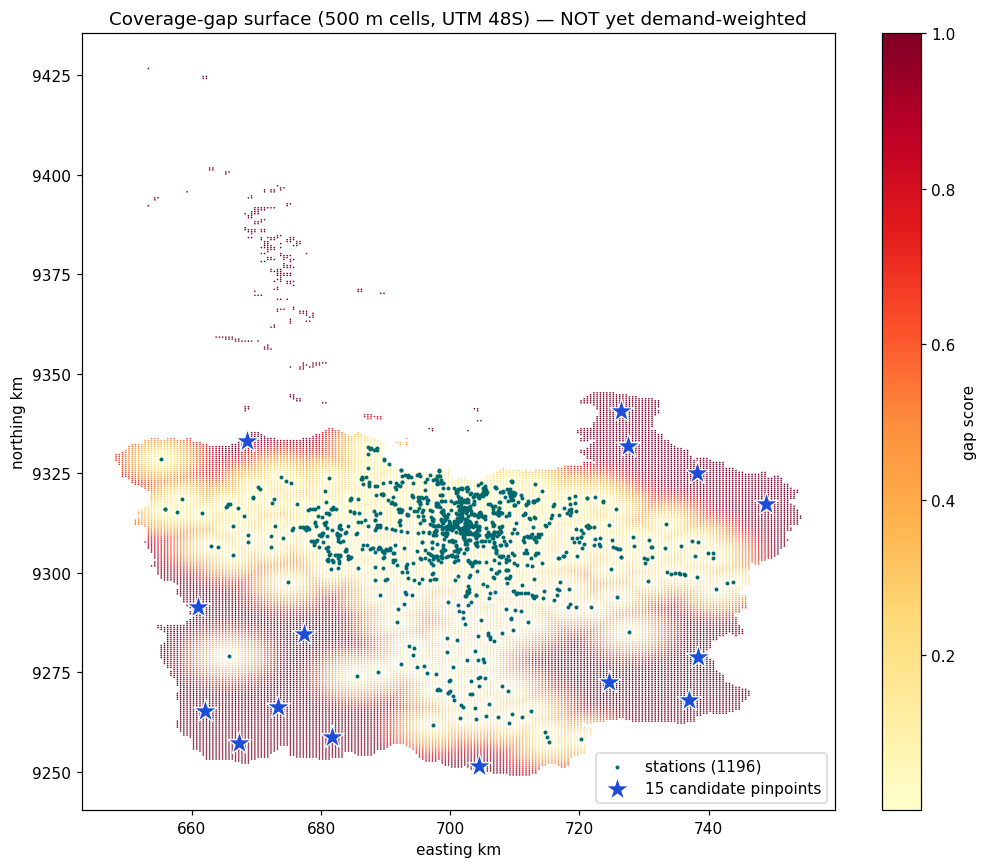

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 8))
sc = ax.scatter(cells.cx/1000, cells.cy/1000, c=cells.gap_score, s=1.1,
                cmap='YlOrRd', linewidths=0)
ax.scatter(in_grid.ux/1000, in_grid.uy/1000, s=2.5, c='#00696F', label=f'stations ({len(in_grid)})')
ax.scatter(candidates.ux/1000, candidates.uy/1000, marker='*', s=260, c='#1d4ed8',
           edgecolors='white', linewidths=0.8, label='15 candidate pinpoints')
ax.set_title('Coverage-gap surface (500 m cells, UTM 48S) — NOT yet demand-weighted')
ax.set_xlabel('easting km'); ax.set_ylabel('northing km')
plt.colorbar(sc, ax=ax, label='gap score'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

Reading the map honestly: the strongest gaps sit in rural Kabupaten Bogor / Kabupaten
Bekasi — far from stations *and* far from demand. That is exactly why phase 1–2 features exist:
population and POI density will re-weight this surface toward where drivers actually are, and the
zoning/MVA mask (phase 3) will remove the cells where nothing may be built.

## 7 · Modelling

### 7.1 The reference method, reproduced on its own data

Target: `EV_stations > 0` per cell. Features: OSM POI counts, road nodes/edges, population.
Two leakage columns are dropped first — the CSV carries its old DataFrame indices
(`Unnamed: 0*`), and a raw index ranked **fourth by importance** when left in. A useful reminder
that a plausible AUC can hide a broken feature matrix.

In [14]:
ref = pd.read_csv(REFERENCE / 'data' / 'processed' / 'all_city_data_with_pop.csv')
leak = [c for c in ref.columns if c.startswith('Unnamed')] + ['Berlin_data_onlycenter_']
ref = ref.drop(columns=[c for c in leak if c in ref.columns])

y = (ref.EV_stations > 0).astype(int)
X = ref.drop(columns=['EV_stations', 'geometry', 'city']).fillna(0)
print(f'{X.shape[0]:,} cells × {X.shape[1]} features | positive class {y.mean():.1%} | cities: {sorted(ref.city.unique())}')

10,824 cells × 19 features | positive class 11.3% | cities: ['Berlin', 'Frankfurt', 'Kaiserslautern', 'Mainz', 'Munich', 'Saarbrucken', 'Stuttgart', 'Trier', 'karlsruhe']


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score

MODELS = {
    'LogisticRegression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    'KNN (k=15)':         make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
    'RandomForest':       RandomForestClassifier(200, random_state=42, n_jobs=-1),
    'GradientBoosting':   GradientBoostingClassifier(random_state=42),
}

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rows = []
for name, m in MODELS.items():
    m.fit(Xtr, ytr)
    proba = m.predict_proba(Xte)[:, 1]
    rows.append([name, roc_auc_score(yte, proba), f1_score(yte, m.predict(Xte)),
                 balanced_accuracy_score(yte, m.predict(Xte))])
random_split = pd.DataFrame(rows, columns=['model', 'AUC', 'F1', 'balanced acc.']).round(3)
random_split.sort_values('AUC', ascending=False)

,model,AUC,F1,balanced acc.
3,GradientBoosting,0.905,0.447,0.657
2,RandomForest,0.889,0.408,0.639
0,LogisticRegression,0.878,0.370,0.621
1,KNN (k=15),0.852,0.283,0.584


### 7.2 The test that matters: does it transfer to an unseen city?

A random split lets the model see every city. Siting a *new* area is a leave-one-city-out
problem — train on five cities, test on the held-out sixth. This is the honest estimate of what
transferring the method to Jabodetabek could achieve.

In [16]:
loco = []
for city in sorted(ref.city.unique()):
    tr, te = ref.city != city, ref.city == city
    m = RandomForestClassifier(200, random_state=42, n_jobs=-1).fit(X[tr], y[tr])
    loco.append([city, int(te.sum()), y[te].mean(),
                 roc_auc_score(y[te], m.predict_proba(X[te])[:, 1])])
loco = pd.DataFrame(loco, columns=['held-out city', 'cells', 'positive rate', 'AUC']).round(3)
print(f"leave-one-city-out mean AUC: {loco.AUC.mean():.3f}  "
      f"(random split gave {random_split.AUC.max():.3f})")
loco

leave-one-city-out mean AUC: 0.893  (random split gave 0.905)


,held-out city,cells,positive rate,AUC
0,Berlin,3891,0.126,0.877
1,Frankfurt,1157,0.048,0.848
2,Kaiserslautern,673,0.031,0.905
3,Mainz,493,0.071,0.910
4,Munich,1426,0.222,0.846
5,Saarbrucken,808,0.052,0.929
6,Stuttgart,961,0.193,0.865
7,Trier,593,0.027,0.966
8,karlsruhe,822,0.072,0.893


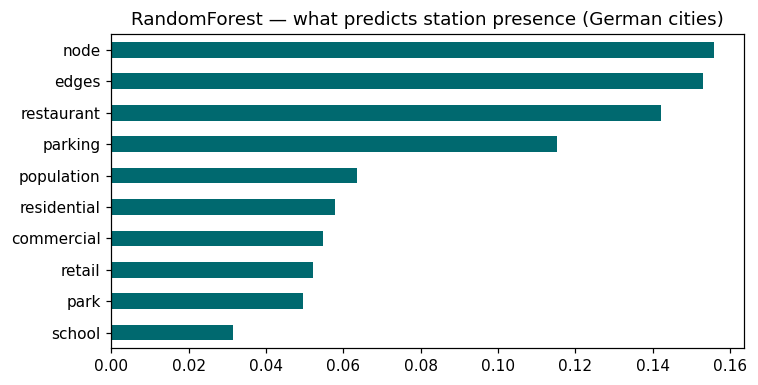

In [17]:
rf = MODELS['RandomForest']
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(10)
imp.plot.barh(figsize=(7, 3.6), color='#00696F',
              title='RandomForest — what predicts station presence (German cities)')
plt.tight_layout(); plt.show()

### 7.3 What transfers to Jabodetabek, and what must not

**Transfers:** the cell framing, the feature families (POI counts, road connectivity,
population), the evaluation discipline (spatial hold-outs, not random splits).

**Must change — two deliberate departures:**

1. **The target.** In Germany, station presence is a market outcome, so "where stations are"
   approximates "where stations belong". In Jabodetabek, 1,080 of our 1,236 stations are PLN
   placements that track PLN offices and policy targets. A presence model here learns to
   recommend more PLN offices. The defensible target is **utilisation** — Zenodo 16946731 carries
   utilisation labels for 137 Greater Jakarta sites (phase 4).
2. **No circular features.** Our phase-0 grid features (`nearest_station_m`, `stations_2km`) are
   *derived from the stations themselves*. Training presence on them would be leakage by
   construction — the model is not trained in this notebook for exactly that reason. They remain
   valid as *inputs to gap scoring* and later as *competition features* for the utilisation model.

**Feature readiness for the reference's matrix:**

| Reference feature family | Ours today | Arrives in |
|---|---|---|
| `EV_stations` (label side) | ✅ 883 positive cells | done (this notebook) |
| road `node` / `edges` | ⚠ graph exists for core Jakarta only, never built at Jabodetabek extent | phase 0/1 |
| POI counts (restaurant, retail, parking, …) | ❌ | phase 1 (Geofabrik PBF) |
| `population` | ❌ | phase 2 (GHS-POP + BPS) |
| land-use shares | ❌ | phase 1 |
| *(new, beyond reference)* MVA headroom, zoning mask | ❌ | phase 3 |
| *(new)* utilisation label | ❌ | phase 4 (Zenodo) |

## 8 · Artifacts & conclusions

In [18]:
grid_out = cells[['cell_id', 'kota', 'overlap_frac', 'ix', 'iy', 'cx', 'cy', 'lon', 'lat',
                  'station_count', 'connector_count',
                  'nearest_station_m', 'stations_2km', 'gap_score', 'has_station']].copy()
grid_out.to_parquet(OUT / 'jabodetabek_grid_features_phase0.parquet', index=False)

cand_out = candidates.copy()
lat0, lon0 = -6.4, 106.75                       # local inverse via numeric refinement
def utm48s_to_wgs84(x, y, lat=lat0, lon=lon0):
    for _ in range(25):
        cx_, cy_ = wgs84_to_utm48s(lat, lon)
        lat += (y - cy_) / 110_570; lon += (x - cx_) / (111_320 * math.cos(math.radians(lat)))
        if abs(cx_ - x) < 0.5 and abs(cy_ - y) < 0.5: break
    return round(lat, 6), round(lon, 6)
cand_out[['latitude', 'longitude']] = [utm48s_to_wgs84(x, y) for x, y in zip(cand_out.ux, cand_out.uy)]
cand_out.to_csv(OUT / 'candidate_pinpoints_phase0.csv', index=False)

for f in sorted(OUT.iterdir()):
    print(f'{f.name:<45} {f.stat().st_size/1024:,.0f} KB')

candidate_pinpoints_phase0.csv                1 KB
jabodetabek_grid_features_phase0.parquet      962 KB


### Conclusions

1. **The station footprint is the asset.** The production pipeline reproduces exactly here:
   3,569 raw → 2,931 deduped → 1,236 in Jabodetabek. Re-labelling the team's grid with it takes
   the positive class from 19 cells to ~880 — the difference between untrainable and workable.
2. **The reference method survives its honest test.** Leave-one-city-out AUC stays usable, so the
   cell-based methodology is worth porting. POI counts and road connectivity dominate the model —
   precisely the features we do not hold yet, which validates the phase 1 priority.
3. **The label must change on our side of the port.** Presence prediction on a policy-placed
   network answers the wrong question; utilisation (Zenodo, 137 sites) answers the right one.
4. **Phase-0 outputs are already useful.** The gap surface and 15 candidate pinpoints are real,
   reproducible, and honestly labelled as coverage-only — the exact contract the
   `/planner/surface.png` and `/planner/candidates` endpoints will serve.
5. **Data debts before ROI numbers can be believed:** demand in our database is simulated
   (`charging_simulation.sql`); occupancy has no date dimension; the road graph must be rebuilt at
   the Jabodetabek extent; RDTR zoning licence is unresolved.